
## Yelp Dataset
### Partes I y II




## 1. Instalación

In [4]:
!pip install ujson networkx tqdm seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 2.7 MB/s eta 0:00:00


## 3. Configuración

In [12]:
BUSINESS_PATH='/content/business_sample.json'
REVIEW_PATH='/content/review_sample.json'

## 4. Imports

In [10]:
import pandas as pd
import numpy as np
import ujson
import networkx as nx
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

## 5. Lectura JSONL

In [6]:
def load_json_lines(filepath,max_rows=None):
    data=[]
    with open(filepath,'r',encoding='utf-8') as f:
        for i,line in enumerate(tqdm(f)):
            data.append(ujson.loads(line))
            if max_rows and i>=max_rows:
                break
    return pd.DataFrame(data)

In [13]:
business_df=load_json_lines(BUSINESS_PATH)
review_df=load_json_lines(REVIEW_PATH)

150346it [00:04, 33493.43it/s]
300001it [00:02, 142425.10it/s]


In [15]:
business_df=business_df[['business_id','name','city','state','stars','review_count','categories']]
review_df=review_df[['review_id','user_id','business_id','stars','date','useful','funny','cool','text']]

business_df.drop_duplicates(inplace=True)
review_df.drop_duplicates(inplace=True)
review_df.dropna(subset=['user_id','business_id','stars'],inplace=True)

Reviews: 300001
Usuarios: 201703
Negocios: 12451


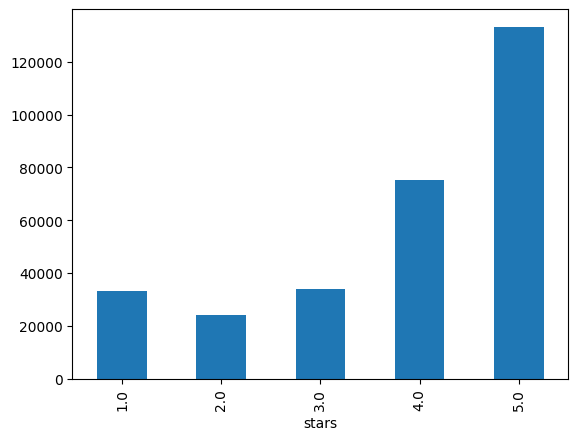

In [16]:
print('Reviews:',len(review_df))
print('Usuarios:',review_df.user_id.nunique())
print('Negocios:',review_df.business_id.nunique())

review_df['stars'].value_counts().sort_index().plot(kind='bar')
plt.show()

## 9. Grafo Usuario-Negocio

In [17]:
sample=review_df.sample(min(100000,len(review_df)),random_state=42)
G=nx.Graph()
for _,row in tqdm(sample.iterrows(),total=len(sample)):
    G.add_edge('U_'+row['user_id'],'B_'+row['business_id'])

100%|██████████| 100000/100000 [00:06<00:00, 16077.70it/s]


## 10. Métricas

In [ ]:
print('Nodos',G.number_of_nodes())
print('Aristas',G.number_of_edges())
print('Densidad',nx.density(G))

largest=max(nx.connected_components(G),key=len)
Gcc=G.subgraph(largest)
print('Diametro',nx.diameter(Gcc))

Nodos 91278
Aristas 99265
Densidad 2.3828607803059293e-05


## 11. PageRank desde cero

In [ ]:
DG=nx.DiGraph()
for _,row in sample.iterrows():
    DG.add_edge(row['user_id'],row['business_id'])

nodes=list(DG.nodes())
idx={n:i for i,n in enumerate(nodes)}
n=len(nodes)
M=np.zeros((n,n))
for node in nodes:
    out=list(DG.successors(node))
    if len(out)==0: continue
    j=idx[node]
    for nbr in out:
        M[idx[nbr],j]=1/len(out)

pr=np.ones(n)/n
d=0.85
for _ in range(50):
    pr=(1-d)/n+d*(M@pr)

pagerank_df=pd.DataFrame({'node':nodes,'score':pr}).sort_values('score',ascending=False)
pagerank_df.head(20)

## 12. HITS desde cero

In [ ]:
A=nx.to_numpy_array(DG)
h=np.ones(A.shape[0])
a=np.ones(A.shape[0])
for _ in range(50):
    a=A.T@h
    a=a/np.linalg.norm(a)
    h=A@a
    h=h/np.linalg.norm(h)

auth_df=pd.DataFrame({'node':nodes,'authority':a}).sort_values('authority',ascending=False)
hub_df=pd.DataFrame({'node':nodes,'hub':h}).sort_values('hub',ascending=False)

auth_df.head(10)
hub_df.head(10)

## 13. Comunidades

In [ ]:
from networkx.algorithms.community import girvan_newman
communities=girvan_newman(G)
first=next(communities)
comms=[list(c) for c in first]
print('Comunidades:',len(comms))
for i,c in enumerate(comms):
    sub=G.subgraph(c)
    print(i+1,'tam=',len(c),'densidad=',nx.density(sub))

## 14. Exportar resultados

In [ ]:
business_df.to_csv('business_clean.csv',index=False)
review_df.to_csv('review_clean.csv',index=False)
pagerank_df.to_csv('pagerank.csv',index=False)
auth_df.to_csv('authorities.csv',index=False)
hub_df.to_csv('hubs.csv',index=False)